In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu-latest/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ids/edabier/miniconda3/envs/hsu-latest/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ids/edabier/miniconda3/envs/hsu-latest/lib/python3.14/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/ids/edabier/miniconda3/envs/hsu-latest/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarn

Using device: cuda:0


/home/ids/edabier/HSU/panopticon/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/ids/edabier/HSU/panopticon/dinov2/layers/attention.py:34: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/ids/edabier/HSU/panopticon/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [2]:
class UnmixingFromUpFeat(nn.Module):
    """
    Unmix from NAF upsampled features + linear regulation
    """
    def __init__(self, D, B, c, H=224):
        """
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi

        """
        super(UnmixingFromUpFeat, self).__init__()
        self.D = D
        self.B = B
        self.c = c
        self.H = H

        self.regul = nn.Linear(self.D, self.D)
        self.abundance_estimator = nn.Sequential(
            nn.Conv2d(D, c, kernel_size=1, bias=False),
            nn.LeakyReLU(0.02),
            nn.BatchNorm2d(c),
            nn.Dropout(0.2)
        )

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_tv_a=0):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        # TV on abundances (sum of difference between consecutive horizontal pixels + vertical pixels)
        loss_tv_a = W_tv_a * tv(A_hat)

        loss = loss_sad + loss_ab + loss_tv_e + loss_tv_a

        return loss

    def get_abundances(self, features):
        features = self.regul(features.permute(0,2,3,1)).permute(0,3,1,2)
        # features = (features - features.mean())/ (1e-8 + features.std())
        A_hat = self.abundance_estimator(features)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features):
        A_hat = self.get_abundances(features)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

In [ ]:
def instantiate_model(model, Y, wavelengths, version="v1", size="large"):
    fm, Y_init_fm, new_H = rsfm.create_fm(model, Y, size=size, version=version, path=global_path)
    _, features = rsfm.extract_f(fm, Y_init_fm, new_H, wavelengths)
    D = int(features.shape[0])
    adapter, naf_upsampler = rsfm.create_naf(model, Y.device)

    return fm, Y_init_fm, new_H, D, adapter, naf_upsampler

def run_one_xp(model, size, dataset, Y_init, A_init, E_init, wavelengths, H, dev, linear=False):

    Y_init = Y_init.to(dev)
    A_init = A_init.to(dev)
    E_init = E_init.to(dev)
    B, c = E_init.shape

    fm, Y_init_fm, new_H, D, adapter, naf_upsampler = instantiate_model(model, Y_init, wavelengths, size=size)
    n_train = 15
    E_hats, A_hats = torch.zeros(n_train, B, c), torch.zeros(n_train, c, new_H, new_H)
    sads, mses = [], []

    for i in range(n_train): 
        
        print(f"Training {i+1}/{n_train}")

        if linear:
            model = UnmixingFromUpFeat(D, B, c, new_H)
        else:
            model = unmx.UnmixingFromUpFeat(D, B, c, new_H)

        model.apply(model.weights_init)
        model = models.init_decoder_weights(model, Y_init_fm/Y_init_fm.max(), c, is_unmixer=True)

        loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev)
        epochs, lr = 200, 0.002

        optim_wrapper = dict(
            optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
            constructor='LayerDecayOptimizerConstructor_ViT',
            paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
        optimizer = build_optim_wrapper(model, optim_wrapper)

        for epoch in range(epochs):
            
            for Y, _, _ in loader:
        
                optimizer.zero_grad()

                Y = utils.oneD_to_2d(Y).to(dev)

                with torch.no_grad():
                    Y_fm, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
                    Y_adapted = adapter(Y_fm)
                    feat_up = naf_upsampler(Y_adapted, utils.oneD_to_2d(features).unsqueeze(0), Y_adapted.shape[-2:])
            
                E_hat, A_hat, Y_hat = model(feat_up)

                loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)

                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
                optimizer.step()
                
                with torch.no_grad():
                    constraints = models.weightConstraint()
                    model.decoder.apply(constraints)
                    
        model.eval()
        
        with torch.no_grad():

            Y_fm, A_init_fm, features = rsfm.extract_f(fm, Y, new_H, wavelengths, A_init)
            Y_adapted = adapter(Y_fm)
            feat_up = naf_upsampler(Y_adapted, utils.oneD_to_2d(features).unsqueeze(0), Y_adapted.shape[-2:])
            E_hat, A_hat, Y_hat = model(feat_up)

            if not E_hat.isnan().any().item() and not A_hat.isnan().any().item():
                sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
                print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
                sads.append(sad)
                mses.append(mse)
            else:
                print(E_hat.isnan().any(), A_hat.isnan().any())

        E_hats[i] = E_hat
        A_hats[i] = A_hat.squeeze(0)

    valid_mask_E = ~torch.isnan(E_hats).any(dim=(1,2))
    valid_E_hats = E_hats[valid_mask_E]
    valid_mask_A = ~torch.isnan(A_hats).any(dim=(1,2,3))
    valid_A_hats = A_hats[valid_mask_A]

    for i in range(n_train):
        if E_hats[i].isnan().any():
            print(E_hats[i].isnan().any(), i)

    if valid_A_hats.shape[0] > 0:
        A_hat_m = torch.mean(valid_A_hats, dim=0)
    if valid_E_hats.shape[0] > 0:
        E_hat_m = torch.mean(valid_E_hats, dim=0)
        sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
        print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")
    else:
        sad, mse = 0, 0
        print("No valid prediction for E_hat, all nans")
    print(sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6)
    return E_hats, A_hats, E_hat_m, A_hat_m

In [4]:
# dataset = "samson"
# data = io.loadmat(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}.mat")
# Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
# E_init = torch.tensor(data["E"], dtype=torch.float)
# A_init = torch.tensor(data["A"], dtype=torch.float)

# Y_init = utils.oneD_to_2d(Y_flat).unsqueeze(0)
# A_init = utils.oneD_to_2d(A_init).unsqueeze(0)
# H = Y_init.shape[-1]

# with open(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt", "r") as file:
#     lines = file.readlines()
#     wavelengths = [float(line.strip()) for line in lines if line.strip()]

# fm, Y_init_fm, new_H, D, adapter, naf_upsampler = instantiate_model("DOFA", Y_init, wavelengths, size="large")
# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev)

# for Y, _, _ in loader:
#     Y = utils.oneD_to_2d(Y).to(dev)
#     Y_fm, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
#     Y_adapted = adapter(Y_fm)
#     feat_up = naf_upsampler(Y_adapted, utils.oneD_to_2d(features).unsqueeze(0), Y_adapted.shape[-2:])

# # regul = nn.Linear(D, D)
# # utils.oneD_to_2d(regul(feat_up.flatten(2))).shape

In [ ]:
# dataset = "samson"
# model = "Panopticon"
# data = io.loadmat(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}.mat")
# Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
# E_init = torch.tensor(data["E"], dtype=torch.float)
# A_init = torch.tensor(data["A"], dtype=torch.float)

# Y_init = utils.oneD_to_2d(Y_flat).unsqueeze(0)
# A_init = utils.oneD_to_2d(A_init).unsqueeze(0)
# H = Y_init.shape[-1]

# with open(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt", "r") as file:
#     lines = file.readlines()
#     wavelengths = [float(line.strip()) for line in lines if line.strip()]

# adapter, naf_upsampler = rsfm.create_naf(model, dev)
# fm, Y_init_fm, new_H = rsfm.create_fm(model, Y_init, size="large", version="v1", path=global_path)

# with torch.no_grad():
#     Y_fm, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)
#     Y_adapted = adapter(Y_fm)
#     feat_up = naf_upsampler(Y_adapted, utils.oneD_to_2d(features).unsqueeze(0), Y_adapted.shape[-2:])
# plots.plot_pca_features(features, title=f"{model} low res features")
# plt.show()
# plots.plot_pca_features(feat_up, title="NAF upsampled features")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3188.48it/s]


Training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.161, NMSE = 0.117
Training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.035, NMSE = 0.031
Training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.103, NMSE = 0.052
Training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.093, NMSE = 0.056
Training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.038, NMSE = 0.032
Training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.037, NMSE = 0.042
Training 7/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.038, NMSE = 0.037

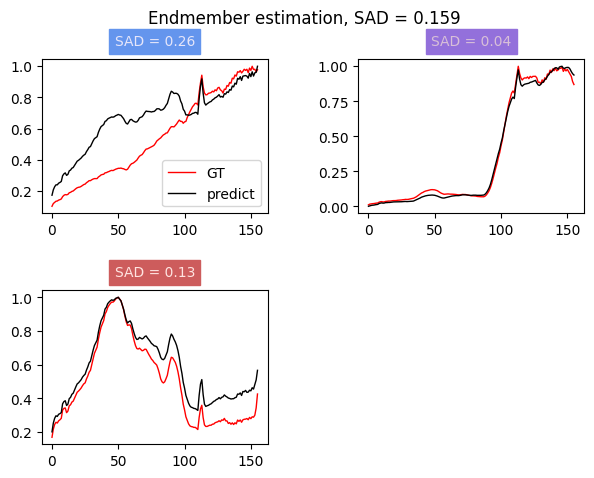

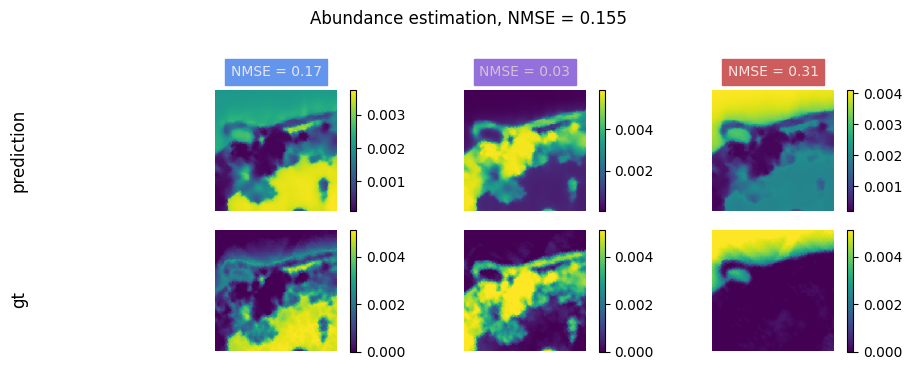

In [18]:
dataset = "samson"
data = io.loadmat(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
E_init = torch.tensor(data["E"], dtype=torch.float)
A_init = torch.tensor(data["A"], dtype=torch.float)

Y_init = utils.oneD_to_2d(Y_flat).unsqueeze(0)
A_init = utils.oneD_to_2d(A_init).unsqueeze(0)
H = Y_init.shape[-1]

with open(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt", "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

# B, c = E_init.shape
# model = UnmixingFromUpFeat(1024, B, c, 224)
# sum(p.numel() for p in model.parameters() if p.requires_grad)/1e9
E_hats, A_hats, E_hat_m, A_hat_m = run_one_xp("SpecAware", "large", dataset, Y_init, A_init, E_init, wavelengths, H, dev, linear=False)